# 03 – Forecasting Models: Day-Ahead Forecasts

Dieses Notebook erzeugt die Forecasts für die spätere Bidding-Evaluation.

## Ziel

Wir trainieren verschiedene Forecasting-Modelle im **Day-Ahead-Setup**.  
Für die Prognose der Produktion zum Zeitpunkt \(t\) werden nur Informationen verwendet, die mindestens 24 Stunden vorher bekannt wären.

## Wichtig

Dieses Notebook bewertet die Modelle **nicht final über RMSE**.  
RMSE, MAE und Pinball Loss dienen nur zur deskriptiven Einordnung.

Der zentrale Vergleich erfolgt später in Notebook 04 über:

```text
Forecast → Bid → Profit / Newsvendor Loss
```

## Modellgruppen

### Point Forecasts
- Persistence 24h
- Elastic Net
- Random Forest
- Gradient Boosting

### Probabilistic Forecasts
- Quantile Regression
- Quantile Regression Forest (QRF)
- Quantile Gradient Boosting
- Quantile Neural Network


## 1. Setup und Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "features_model_all_sites.csv"

RESULTS_DIR = PROJECT_ROOT / "results"
FORECAST_DIR = RESULTS_DIR / "forecasts"
MODELS_DIR = RESULTS_DIR / "models"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

for directory in [FORECAST_DIR, MODELS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)


Project root: C:\Users\felix\Documents\AI1\wind_bidding_project
Data path: C:\Users\felix\Documents\AI1\wind_bidding_project\data\processed\features_model_all_sites.csv


## 2. Modell-Imports aus `src.models`

In [2]:
from src.models import (
    elastic_net,
    random_forest,
    gradient_boosting,
    quantile_regression,
    quantile_regression_forest,
    quantile_gradient_boosting,
    quantile_neural_network,
)


## 3. Daten laden

Erwartete Eingabedatei:

```text
data/processed/features_model_all_sites.csv
```

Mindestens benötigte Spalten:

```text
timestamp
power
```

Optional:

```text
wind_speed
```


In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
df.head()


Shape: (297244, 98)


,site,timestamp,power,wind_speed_obs,energy_mwh,solar_zenith,solar_azimuth,clearsky_ghi,clearsky_dni,clearsky_dhi,...,cams_clearsky_index_lag3h,cams_clearsky_index_lag6h,cams_clearsky_index_lag12h,cams_clearsky_index_lag24h,cams_clearsky_index_rollmean3h,cams_clearsky_index_rollstd3h,cams_clearsky_index_rollmean6h,cams_clearsky_index_rollstd6h,cams_clearsky_index_rollmean24h,cams_clearsky_index_rollstd24h
0,Schonungen,2014-01-02 00:00:00,342.166667,6.166667,0.342167,152.540576,348.783631,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Schonungen,2014-01-02 01:00:00,451.500000,6.516667,0.451500,151.905356,18.636757,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Schonungen,2014-01-02 02:00:00,499.500000,6.716667,0.499500,146.853384,44.090171,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Schonungen,2014-01-02 03:00:00,314.333333,5.750000,0.314333,139.086517,63.186658,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Schonungen,2014-01-02 04:00:00,246.333333,5.316667,0.246333,130.015628,77.867891,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Day-Ahead Feature Engineering (Gate-Close-Referenzierung)

Alle Gebote für Tag D+1 werden um **12:00 Uhr Mittag** von Tag D abgegeben (EPEX Gate Close).
Deshalb wird jedes Feature relativ zum **Gate-Close-Zeitpunkt** berechnet:

$$\text{gate\_close}(t) = \text{midnight}(t) - 12\,\text{h} = \text{noon of day } D$$

Alle 24 Zielstunden teilen denselben Gate-Close und damit exakt dieselbe Informationsbasis.
Das vermeidet sowohl Data Leakage als auch die Inkonsistenz eines fixen relativen Lags
(lag\_36 war für Zielstunde 0 = 12 h Abstand, für Stunde 23 = 59 h Abstand).

In [4]:
df_model = df.copy()

# Ensure timestamp is datetime
df_model["timestamp"] = pd.to_datetime(df_model["timestamp"], errors="coerce")

df_model["energy_mwh"] = df_model["power"].clip(lower=0) / 1000

df_model["hour"]      = df_model["timestamp"].dt.hour
df_model["dayofweek"] = df_model["timestamp"].dt.dayofweek
df_model["month"]     = df_model["timestamp"].dt.month

,site,timestamp,power,wind_speed_obs,energy_mwh,solar_zenith,solar_azimuth,clearsky_ghi,clearsky_dni,clearsky_dhi,...,energy_roll168_at_gate,energy_roll_std168_at_gate,wind_at_gate,wind_gate_m12h,wind_gate_m24h,wind_gate_m168h,wind_roll24_at_gate,wind_roll_std24_at_gate,wind_roll168_at_gate,wind_roll_std168_at_gate
0,Schonungen,2014-01-02 00:00:00,342.166667,6.166667,0.342167,152.540576,348.783631,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Schonungen,2014-01-02 01:00:00,451.500000,6.516667,0.451500,151.905356,18.636757,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Schonungen,2014-01-02 02:00:00,499.500000,6.716667,0.499500,146.853384,44.090171,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Schonungen,2014-01-02 03:00:00,314.333333,5.750000,0.314333,139.086517,63.186658,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Schonungen,2014-01-02 04:00:00,246.333333,5.316667,0.246333,130.015628,77.867891,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Feature-Set und Zielvariable

In [5]:
BASE_FEATURES = [
    "energy_at_gate",            
    "energy_gate_m12h",          
    "energy_gate_m24h",          
    "energy_gate_m48h",          
    "energy_gate_m168h",         
    "energy_roll24_at_gate",     
    "energy_roll_std24_at_gate", 
    "energy_roll168_at_gate",    
    "energy_roll_std168_at_gate",
    "hour_sin", "hour_cos",      
    "dow_sin",  "dow_cos",       
    "month_sin", "month_cos",     
]

WIND_LAG_FEATURES = [f for f in [
    "wind_at_gate",
    "wind_gate_m12h",
    "wind_gate_m24h",
    "wind_gate_m168h",
    "wind_roll24_at_gate",
    "wind_roll_std24_at_gate",
    "wind_roll168_at_gate",
    "wind_roll_std168_at_gate",
] if f in df_model.columns]

NWP_FEATURES = [f for f in [
    "nwp_ws100", "nwp_ws10", "nwp_wd100", "nwp_wd10",
    "nwp_temp2m", "nwp_surface_pressure", "nwp_total_cloud_cover",
    "nwp_wind_shear_diff", "nwp_wind_shear_ratio",
    "nwp_sin_wd100", "nwp_cos_wd100", "nwp_sin_wd10", "nwp_cos_wd10",
    "nwp_ws100_lag3h", "nwp_ws100_lag6h", "nwp_ws100_lag12h", "nwp_ws100_lag24h",
    "nwp_ws100_rollmean3h", "nwp_ws100_rollmean6h", "nwp_ws100_rollmean24h",
    "nwp_temp2m_lag3h", "nwp_temp2m_lag6h", "nwp_temp2m_lag12h",
] if f in df_model.columns]

CAMS_FEATURES = [f for f in [
    "cams_ghi", "cams_clearsky_index",
    "cams_ghi_lag3h", "cams_ghi_lag6h", "cams_ghi_lag12h", "cams_ghi_lag24h",
    "cams_clearsky_index_lag3h", "cams_clearsky_index_lag6h", "cams_clearsky_index_lag12h", "cams_clearsky_index_lag24h",
    "cams_ghi_rollmean3h", "cams_ghi_rollmean6h", "cams_ghi_rollmean24h",
    "cams_clearsky_index_rollmean3h", "cams_clearsky_index_rollmean6h", "cams_clearsky_index_rollmean24h",
] if f in df_model.columns]

FEATURES_DAY_AHEAD = BASE_FEATURES + WIND_LAG_FEATURES + NWP_FEATURES + CAMS_FEATURES

TARGET = "energy_mwh"

df_model = df_model.dropna(subset=FEATURES_DAY_AHEAD + [TARGET]).reset_index(drop=True)

X = df_model[FEATURES_DAY_AHEAD]
y = df_model[TARGET]

print("Number of observations:", len(df_model))
print("Number of features:", len(FEATURES_DAY_AHEAD))
print(f"  Gate-Close rolling: {len(BASE_FEATURES + WIND_LAG_FEATURES)}")
print(f"  NWP (operative forecasts): {len(NWP_FEATURES)}")
print(f"  CAMS (satellite): {len(CAMS_FEATURES)}")
print("\nFeatures by category:")
print(f"  Energy/Wind gate-close: {[f for f in FEATURES_DAY_AHEAD if 'energy' in f or 'wind' in f][:3]}...")
print(f"  NWP: {NWP_FEATURES[:3]}...")
print(f"  CAMS: {CAMS_FEATURES[:3]}...")
X.head()

Number of observations: 20924
Number of features: 52
  Gate-Close rolling: 23
  NWP (operative forecasts): 13
  CAMS (satellite): 16

Features by category:
  Energy/Wind gate-close: ['energy_at_gate', 'energy_gate_m12h', 'energy_gate_m24h']...
  NWP: ['nwp_ws100', 'nwp_ws10', 'nwp_wd100']...
  CAMS: ['cams_ghi', 'cams_clearsky_index', 'cams_ghi_lag3h']...


,energy_at_gate,energy_gate_m12h,energy_gate_m24h,energy_gate_m48h,energy_gate_m168h,energy_roll24_at_gate,energy_roll_std24_at_gate,energy_roll168_at_gate,energy_roll_std168_at_gate,hour_sin,...,cams_clearsky_index_lag3h,cams_clearsky_index_lag6h,cams_clearsky_index_lag12h,cams_clearsky_index_lag24h,cams_ghi_rollmean3h,cams_ghi_rollmean6h,cams_ghi_rollmean24h,cams_clearsky_index_rollmean3h,cams_clearsky_index_rollmean6h,cams_clearsky_index_rollmean24h
0,1.214917,1.695500,0.241583,0.476833,0.988667,1.359010,0.676394,1.449881,0.865647,-1.0,...,0.392062,0.238863,0.130146,0.84104,119.235867,140.792533,56.207354,0.687034,0.493630,0.414602
1,1.214917,1.695500,0.241583,0.476833,0.988667,1.359010,0.676394,1.449881,0.865647,-1.0,...,0.413585,0.227605,1.000000,1.00000,109.948767,124.147200,62.100354,0.626699,0.438490,0.575728
2,1.283917,1.857667,1.214917,0.241583,0.327750,1.453722,0.516632,1.494850,0.864230,-1.0,...,0.236256,0.310871,0.124592,1.00000,47.309967,111.460233,60.988804,0.187931,0.251591,0.379109
3,1.283917,1.857667,1.214917,0.241583,0.327750,1.453722,0.516632,1.494850,0.864230,-1.0,...,0.770416,0.549491,0.125741,1.00000,192.446800,265.560650,102.691279,0.917412,0.764132,0.612952
4,0.466167,0.562000,1.283917,1.214917,1.373750,0.507031,0.279027,1.308562,0.889044,-1.0,...,0.582399,0.196710,0.642719,0.13232,118.387833,133.789250,60.259033,0.424011,0.346117,0.387588


## 6. Zeitlicher Train-Test-Split

In [6]:
TEST_SIZE = 0.2

split_idx = int(len(df_model) * (1 - TEST_SIZE))

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

test_timestamps = df_model.loc[X_test.index, "timestamp"].reset_index(drop=True)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Test period:", test_timestamps.min(), "bis", test_timestamps.max())


Train: (16739, 52) (16739,)
Test: (4185, 52) (4185,)
Test period: 2024-06-04 21:00:00 bis 2025-08-31 19:00:00


## 7. Hilfsfunktionen für deskriptive Forecast-Metriken

In [7]:

def evaluate_point_forecast(y_true, y_pred) -> dict[str, float]:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }


def add_point_metrics(rows: list[dict], model_name: str, y_true, y_pred) -> None:
    row = {"model": model_name}
    row.update(evaluate_point_forecast(y_true, y_pred))
    rows.append(row)


def clip_non_negative(values):
    """
    Ensure non-negative wind energy forecasts.
    Wind production cannot be negative.
    """
    return np.clip(np.asarray(values, dtype=float), 0, None)


def enforce_quantile_monotonicity(preds: pd.DataFrame) -> pd.DataFrame:
    """
    Enforce q10 <= q25 <= q50 <= q75 <= q90 row-wise.

    This is a pragmatic post-processing step to avoid quantile crossing
    when quantile models are trained independently.
    """
    quantile_cols = [col for col in preds.columns if col.startswith("q")]

    if not quantile_cols:
        return preds.copy()

    fixed = preds.copy()
    fixed[quantile_cols] = np.sort(fixed[quantile_cols].to_numpy(), axis=1)
    return fixed


def check_quantile_monotonicity(preds: pd.DataFrame, model_name: str) -> None:
    """
    Print whether quantile predictions are monotonic.
    """
    quantile_cols = [col for col in preds.columns if col.startswith("q")]

    if not quantile_cols:
        print(f"{model_name}: no quantile columns found.")
        return

    values = preds[quantile_cols].to_numpy()
    violations = np.sum(np.any(np.diff(values, axis=1) < 0, axis=1))

    if violations == 0:
        print(f"{model_name}: quantiles are monotonic.")
    else:
        print(f"{model_name}: fixed {violations} rows with quantile crossing.")


# Teil A – Point Forecast Models

Point Forecasts liefern genau einen Vorhersagewert pro Zeitpunkt.  
Sie werden später im Bidding als direktes Gebot interpretiert:

\[
b_t = \hat{y}_t
\]

Im finalen Vergleich werden sie nicht über RMSE gegen probabilistische Modelle ausgespielt, sondern über ihre wirtschaftliche Bidding-Performance.


## 8. Point Forecasts trainieren

In [8]:
point_metrics_rows = []

# Persistence (Gate): Vorhersage = Produktion zum Gate-Close-Zeitpunkt für alle 24h des Folgetags.
y_pred_persistence_gate = df_model.loc[X_test.index, "energy_at_gate"].to_numpy()
y_pred_persistence_gate = clip_non_negative(y_pred_persistence_gate)

en_model = elastic_net.train(
    X_train,
    y_train,
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42,
)
y_pred_elastic_net = elastic_net.predict(en_model, X_test)
y_pred_elastic_net = clip_non_negative(y_pred_elastic_net)

rf_model = random_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
)
y_pred_random_forest = random_forest.predict(rf_model, X_test)
y_pred_random_forest = clip_non_negative(y_pred_random_forest)

gb_model = gradient_boosting.train(
    X_train, y_train,
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=20,
)
y_pred_gradient_boosting = gradient_boosting.predict(gb_model, X_test)
y_pred_gradient_boosting = clip_non_negative(y_pred_gradient_boosting)

point_predictions = {
    "Persistence_gate":  y_pred_persistence_gate,
    "Elastic_Net":       y_pred_elastic_net,
    "Random_Forest":     y_pred_random_forest,
    "Gradient_Boosting": y_pred_gradient_boosting,
}

for model_name, y_pred in point_predictions.items():
    add_point_metrics(point_metrics_rows, model_name, y_test, y_pred)

point_metrics = pd.DataFrame(point_metrics_rows).sort_values("RMSE")
point_metrics

,model,MAE,RMSE,R2
2,Random_Forest,0.246318,0.376649,0.490139
3,Gradient_Boosting,0.250072,0.383806,0.470579
1,Elastic_Net,0.272375,0.406747,0.405398
0,Persistence_gate,0.400837,0.617737,-0.371466


## 9. Deskriptive Grafik: Point Forecast RMSE

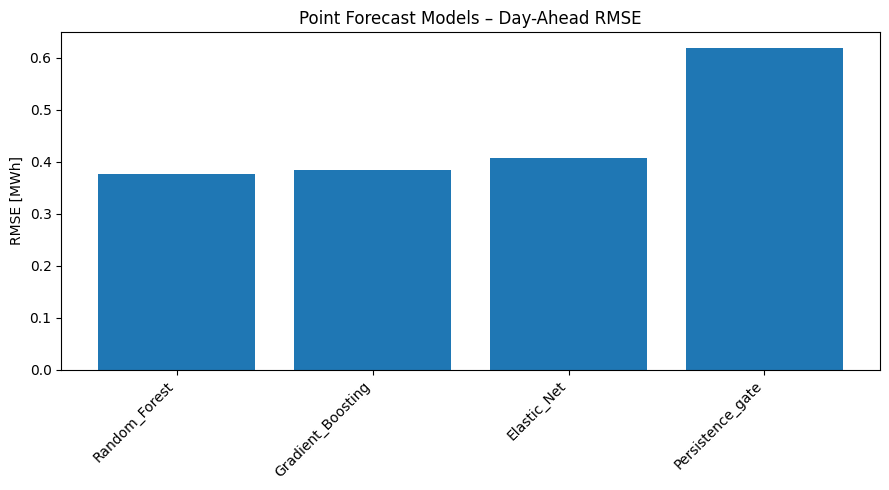

In [9]:
plot_df = point_metrics.sort_values("RMSE")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE [MWh]")
plt.title("Point Forecast Models – Day-Ahead RMSE")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "point_forecast_rmse_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


# Teil B – Probabilistic Forecast Models

Probabilistische Modelle liefern mehrere Quantile pro Zeitpunkt.

Für das Newsvendor-Bidding ist das besonders relevant, weil je nach Kostenstruktur unterschiedliche Quantile als Gebot verwendet werden können.


## 10. Probabilistische Modelle trainieren

In [10]:

QUANTILES = (0.1, 0.25, 0.5, 0.75, 0.9)

prob_median_metrics_rows = []
pinball_rows = []

# Quantile Regression
qr_models = quantile_regression.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
)
qr_preds = quantile_regression.predict_all(qr_models, X_test)
qr_preds = enforce_quantile_monotonicity(qr_preds).clip(lower=0)
check_quantile_monotonicity(qr_preds, "Quantile Regression")

y_pred_qr_q50 = qr_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Regression_q50", y_test, y_pred_qr_q50)

qr_pinball = quantile_regression.evaluate_quantiles(y_test, qr_preds)
qr_pinball["model"] = "Quantile_Regression"
pinball_rows.append(qr_pinball)

# Quantile Regression Forest
qrf_model = quantile_regression_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42,
)
qrf_preds = quantile_regression_forest.predict_all(
    qrf_model,
    X_test,
    quantiles=QUANTILES,
)
qrf_preds = enforce_quantile_monotonicity(qrf_preds).clip(lower=0)
check_quantile_monotonicity(qrf_preds, "QRF")

y_pred_qrf_q50 = qrf_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "QRF_q50", y_test, y_pred_qrf_q50)

qrf_pinball = quantile_regression_forest.evaluate_quantiles(y_test, qrf_preds)
qrf_pinball["model"] = "QRF"
pinball_rows.append(qrf_pinball)

# Quantile Gradient Boosting
qgb_models = quantile_gradient_boosting.train(
    X_train, y_train,
    quantiles=QUANTILES,
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=20,
)
qgb_preds = quantile_gradient_boosting.predict_all(qgb_models, X_test)
qgb_preds = enforce_quantile_monotonicity(qgb_preds).clip(lower=0)
check_quantile_monotonicity(qgb_preds, "Quantile Gradient Boosting")

y_pred_qgb_q50 = qgb_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Gradient_Boosting_q50", y_test, y_pred_qgb_q50)

qgb_pinball = quantile_gradient_boosting.evaluate_quantiles(y_test, qgb_preds)
qgb_pinball["model"] = "Quantile_Gradient_Boosting"
pinball_rows.append(qgb_pinball)

# Quantile Neural Network
qnn_model = quantile_neural_network.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
    hidden_layer_sizes=(64, 32),
    dropout=0.1,
    learning_rate=0.001,
    weight_decay=0.0001,
    batch_size=64,
    max_epochs=500,
    patience=30,
    random_state=42,
)
qnn_preds = quantile_neural_network.predict_all(qnn_model, X_test)
qnn_preds = enforce_quantile_monotonicity(qnn_preds).clip(lower=0)
check_quantile_monotonicity(qnn_preds, "Quantile Neural Network")

y_pred_qnn_q50 = qnn_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Neural_Network_q50", y_test, y_pred_qnn_q50)

qnn_pinball = quantile_neural_network.evaluate_quantiles(y_test, qnn_preds)
qnn_pinball["model"] = "Quantile_Neural_Network"
pinball_rows.append(qnn_pinball)

prob_median_metrics = pd.DataFrame(prob_median_metrics_rows).sort_values("RMSE")
pinball_metrics = pd.concat(pinball_rows, ignore_index=True)
pinball_metrics = pinball_metrics[["model", "quantile", "pinball_loss"]]

prob_median_metrics


Quantile Regression: quantiles are monotonic.


QRF: quantiles are monotonic.


Quantile Gradient Boosting: quantiles are monotonic.


Quantile Neural Network: quantiles are monotonic.


,model,MAE,RMSE,R2
1,QRF_q50,0.234454,0.380889,0.478595
3,Quantile_Neural_Network_q50,0.233515,0.384553,0.468515
2,Quantile_Gradient_Boosting_q50,0.237622,0.398539,0.429155
0,Quantile_Regression_q50,0.253570,0.417356,0.373976


## 11. Pinball Loss der probabilistischen Modelle

In [11]:
pinball_metrics.sort_values(["quantile", "pinball_loss"])


,model,quantile,pinball_loss
15,Quantile_Neural_Network,0.10,0.038896
0,Quantile_Regression,0.10,0.039848
5,QRF,0.10,0.040206
10,Quantile_Gradient_Boosting,0.10,0.041022
16,Quantile_Neural_Network,0.25,0.079956
6,QRF,0.25,0.080997
11,Quantile_Gradient_Boosting,0.25,0.082856
1,Quantile_Regression,0.25,0.085269
17,Quantile_Neural_Network,0.50,0.116757
7,QRF,0.50,0.117227


## 12. Deskriptive Grafik: Pinball Loss

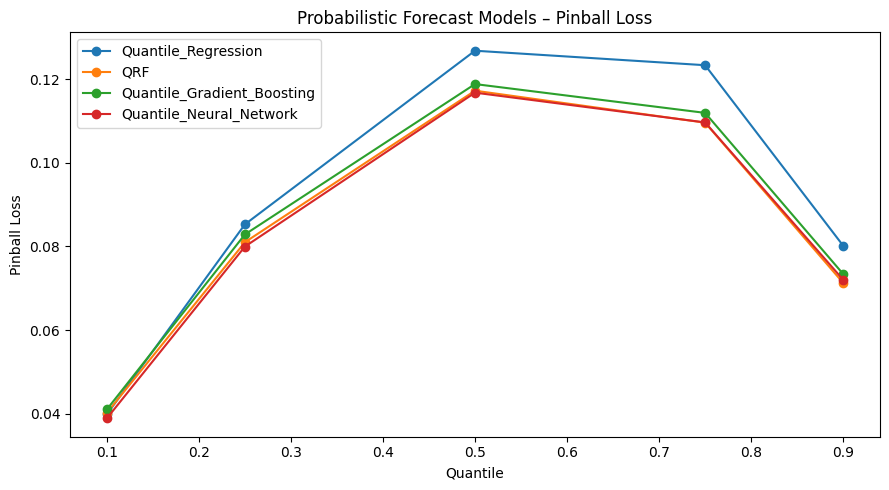

In [12]:
plt.figure(figsize=(9, 5))

for model_name in pinball_metrics["model"].unique():
    subset = pinball_metrics[pinball_metrics["model"] == model_name].sort_values("quantile")
    plt.plot(
        subset["quantile"],
        subset["pinball_loss"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Quantile")
plt.ylabel("Pinball Loss")
plt.title("Probabilistic Forecast Models – Pinball Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "probabilistic_pinball_loss_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Beispielgrafik: Quantile-Band

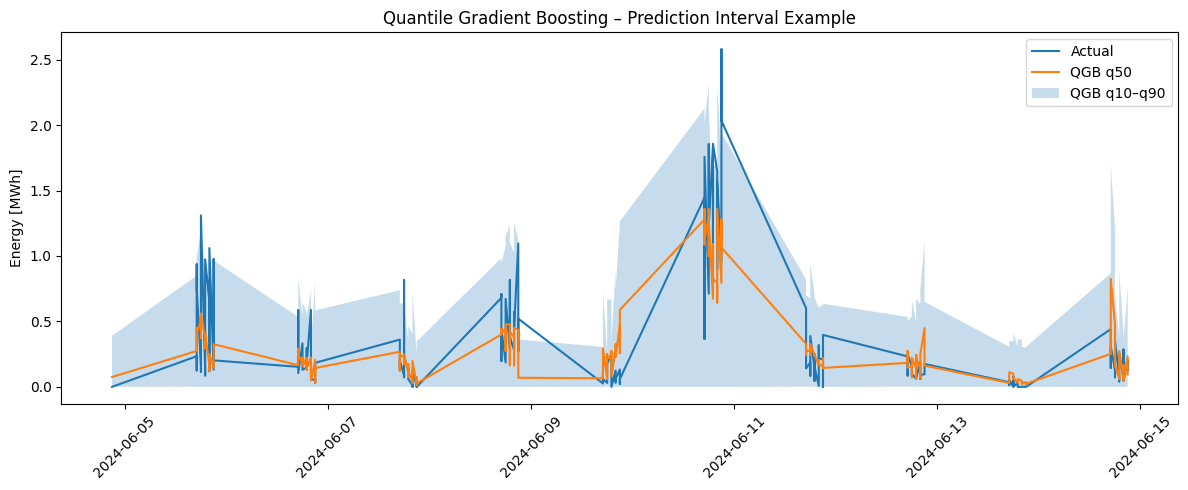

In [13]:
plot_window = min(200, len(y_test))

plot_data = pd.DataFrame({
    "timestamp": test_timestamps.iloc[:plot_window],
    "actual": y_test.iloc[:plot_window].to_numpy(),
    "q10": qgb_preds["q10"].iloc[:plot_window].to_numpy(),
    "q50": qgb_preds["q50"].iloc[:plot_window].to_numpy(),
    "q90": qgb_preds["q90"].iloc[:plot_window].to_numpy(),
})

plt.figure(figsize=(12, 5))
plt.plot(plot_data["timestamp"], plot_data["actual"], label="Actual")
plt.plot(plot_data["timestamp"], plot_data["q50"], label="QGB q50")
plt.fill_between(
    plot_data["timestamp"],
    plot_data["q10"],
    plot_data["q90"],
    alpha=0.25,
    label="QGB q10–q90",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Quantile Gradient Boosting – Prediction Interval Example")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "qgb_prediction_interval_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


# Teil C – Gemeinsame Forecast Outputs

## 14. Gemeinsames Predictions-DataFrame erstellen

In [14]:
predictions = pd.DataFrame({
    "timestamp": test_timestamps.values,
    "y_true": y_test.to_numpy(),

    "persistence_gate": y_pred_persistence_gate,
    "elastic_net": y_pred_elastic_net,
    "random_forest": y_pred_random_forest,
    "gradient_boosting": y_pred_gradient_boosting,

    "quantile_regression_q10": qr_preds["q10"].to_numpy(),
    "quantile_regression_q25": qr_preds["q25"].to_numpy(),
    "quantile_regression_q50": qr_preds["q50"].to_numpy(),
    "quantile_regression_q75": qr_preds["q75"].to_numpy(),
    "quantile_regression_q90": qr_preds["q90"].to_numpy(),

    "qrf_q10": qrf_preds["q10"].to_numpy(),
    "qrf_q25": qrf_preds["q25"].to_numpy(),
    "qrf_q50": qrf_preds["q50"].to_numpy(),
    "qrf_q75": qrf_preds["q75"].to_numpy(),
    "qrf_q90": qrf_preds["q90"].to_numpy(),

    "qgb_q10": qgb_preds["q10"].to_numpy(),
    "qgb_q25": qgb_preds["q25"].to_numpy(),
    "qgb_q50": qgb_preds["q50"].to_numpy(),
    "qgb_q75": qgb_preds["q75"].to_numpy(),
    "qgb_q90": qgb_preds["q90"].to_numpy(),

    "qnn_q10": qnn_preds["q10"].to_numpy(),
    "qnn_q25": qnn_preds["q25"].to_numpy(),
    "qnn_q50": qnn_preds["q50"].to_numpy(),
    "qnn_q75": qnn_preds["q75"].to_numpy(),
    "qnn_q90": qnn_preds["q90"].to_numpy(),
})

print(predictions.shape)
predictions.head()

(4185, 26)


,timestamp,y_true,persistence_gate,elastic_net,random_forest,gradient_boosting,quantile_regression_q10,quantile_regression_q25,quantile_regression_q50,quantile_regression_q75,...,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qnn_q10,qnn_q25,qnn_q50,qnn_q75,qnn_q90
0,2024-06-04 21:00:00,0.000000,0.029583,0.207242,0.079982,0.141198,0.000000,0.000000,0.035756,0.223804,...,0.000000,0.019847,0.075060,0.216461,0.390402,0.000741,0.010297,0.052460,0.177125,0.346327
1,2024-06-05 17:00:00,0.233667,0.024000,0.497904,0.363914,0.366084,0.076369,0.203459,0.423239,0.776435,...,0.000951,0.149094,0.274060,0.483563,0.849044,0.023575,0.109817,0.247120,0.468363,0.826192
2,2024-06-05 17:00:00,0.125167,0.024000,0.647750,0.581614,0.549906,0.109424,0.287059,0.551773,0.997576,...,0.000000,0.271130,0.449056,0.725001,1.173989,0.068362,0.207375,0.428584,0.731669,1.173639
3,2024-06-05 17:00:00,0.936460,0.024000,0.614354,0.498356,0.475985,0.094523,0.231965,0.448832,0.834088,...,0.000000,0.242306,0.405965,0.670695,0.886548,0.076241,0.202013,0.378701,0.631763,0.952908
4,2024-06-05 17:00:00,0.755000,0.024000,0.614397,0.608741,0.494442,0.101602,0.271933,0.522707,0.958965,...,0.000000,0.242306,0.405965,0.670695,0.999554,0.131257,0.301339,0.575443,0.902925,1.319131


## 15. Beispielgrafik: Actual vs. ausgewählte Forecasts

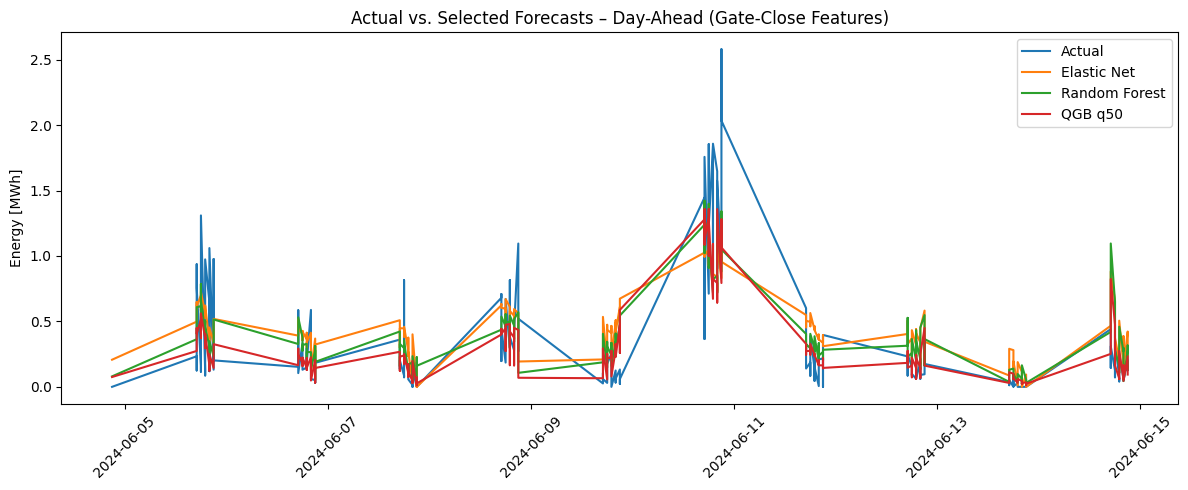

In [15]:
plot_window = min(200, len(predictions))

plt.figure(figsize=(12, 5))

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["y_true"].iloc[:plot_window],
    label="Actual",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["elastic_net"].iloc[:plot_window],
    label="Elastic Net",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["random_forest"].iloc[:plot_window],
    label="Random Forest",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["qgb_q50"].iloc[:plot_window],
    label="QGB q50",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Actual vs. Selected Forecasts – Day-Ahead (Gate-Close Features)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "actual_vs_selected_forecasts_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()

## Hinweis zu xAI

Die erklärende Analyse der Modelle erfolgt nicht in diesem Forecasting-Notebook, sondern in Notebook 05.

Dort sollten insbesondere folgende Aspekte betrachtet werden:

- Koeffizienten von Elastic Net als interpretierbares Modell
- Feature Importances und SHAP für Random Forest, Gradient Boosting, QRF und Quantile Gradient Boosting
- Analyse von Zeitpunkten mit hohen Bidding-Verlusten aus Notebook 04

Notebook 03 erzeugt dafür nur die Forecasts, Modelle und Testfeatures.


## 16. Outputs speichern

In [16]:
predictions_path = FORECAST_DIR / "predictions_day_ahead.csv"
features_path = FORECAST_DIR / "test_features_day_ahead.csv"

point_metrics_path = TABLES_DIR / "point_forecast_metrics_day_ahead.csv"
prob_median_metrics_path = TABLES_DIR / "probabilistic_median_metrics_day_ahead.csv"
pinball_metrics_path = TABLES_DIR / "pinball_metrics_day_ahead.csv"

predictions.to_csv(predictions_path, index=False)
X_test.reset_index(drop=True).to_csv(features_path, index=False)

point_metrics.to_csv(point_metrics_path, index=False)
prob_median_metrics.to_csv(prob_median_metrics_path, index=False)
pinball_metrics.to_csv(pinball_metrics_path, index=False)

print("Saved:", predictions_path)
print("Saved:", features_path)
print("Saved:", point_metrics_path)
print("Saved:", prob_median_metrics_path)
print("Saved:", pinball_metrics_path)


Saved: C:\Users\felix\Documents\AI1\wind_bidding_project\results\forecasts\predictions_day_ahead.csv
Saved: C:\Users\felix\Documents\AI1\wind_bidding_project\results\forecasts\test_features_day_ahead.csv
Saved: C:\Users\felix\Documents\AI1\wind_bidding_project\results\tables\point_forecast_metrics_day_ahead.csv
Saved: C:\Users\felix\Documents\AI1\wind_bidding_project\results\tables\probabilistic_median_metrics_day_ahead.csv
Saved: C:\Users\felix\Documents\AI1\wind_bidding_project\results\tables\pinball_metrics_day_ahead.csv


## 17. Modelle speichern

In [17]:
joblib.dump(en_model, MODELS_DIR / "elastic_net_day_ahead.joblib")
joblib.dump(rf_model, MODELS_DIR / "random_forest_day_ahead.joblib")
joblib.dump(gb_model, MODELS_DIR / "gradient_boosting_day_ahead.joblib")

joblib.dump(qr_models, MODELS_DIR / "quantile_regression_day_ahead.joblib")
joblib.dump(qrf_model, MODELS_DIR / "qrf_day_ahead.joblib")
joblib.dump(qgb_models, MODELS_DIR / "quantile_gradient_boosting_day_ahead.joblib")
joblib.dump(qnn_model, MODELS_DIR / "quantile_neural_network_day_ahead.joblib")

print("Saved models to:", MODELS_DIR)


Saved models to: C:\Users\felix\Documents\AI1\wind_bidding_project\results\models


## 18. Zusammenfassung

In [18]:
print("Point Forecast Metrics")
display(point_metrics)

print("Probabilistic Median Metrics")
display(prob_median_metrics)

print("Pinball Metrics")
display(pinball_metrics.sort_values(["quantile", "pinball_loss"]))


Point Forecast Metrics


,model,MAE,RMSE,R2
2,Random_Forest,0.246318,0.376649,0.490139
3,Gradient_Boosting,0.250072,0.383806,0.470579
1,Elastic_Net,0.272375,0.406747,0.405398
0,Persistence_gate,0.400837,0.617737,-0.371466


Probabilistic Median Metrics


,model,MAE,RMSE,R2
1,QRF_q50,0.234454,0.380889,0.478595
3,Quantile_Neural_Network_q50,0.233515,0.384553,0.468515
2,Quantile_Gradient_Boosting_q50,0.237622,0.398539,0.429155
0,Quantile_Regression_q50,0.253570,0.417356,0.373976


Pinball Metrics


,model,quantile,pinball_loss
15,Quantile_Neural_Network,0.10,0.038896
0,Quantile_Regression,0.10,0.039848
5,QRF,0.10,0.040206
10,Quantile_Gradient_Boosting,0.10,0.041022
16,Quantile_Neural_Network,0.25,0.079956
6,QRF,0.25,0.080997
11,Quantile_Gradient_Boosting,0.25,0.082856
1,Quantile_Regression,0.25,0.085269
17,Quantile_Neural_Network,0.50,0.116757
7,QRF,0.50,0.117227
